# Data Science Lab on Smart Cities

## Decoding the Intersection between Ridesourcing Dependency and Socio-Demographic Vulnerability in the Chicago FUA

Research question: Is ridesourcing acting as a mobility equalizer or as a costly substitute for inadequate public transport in vulnerable peripheral areas of Chicago?

**Analysis flow**

1. Data sources
2. Transport Usage Index (TUI)
3. Socio-Demographic Vulnerability Index (SDVI)
4. TUI vs vulnerability (correlations and maps)
5. Weighted TUI (Financial Burden Index)
6. Ridesharing travel time to the Loop

## 1. Data Sources

- CMAP Community Data Snapshots — [ArcGIS FeatureServer](https://services5.arcgis.com/LcMXE3TFhi1BSaCY/arcgis/rest/services/CommunityDataSnapshots_2015_2025_gdb/FeatureServer) · [Data Hub](https://datahub.cmap.illinois.gov/search?tags=community%2520data%2520snapshots)
- Transportation Network Providers trips (Chicago Data Portal): [2018–2022](https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2018-2022-/m6dm-c72p/data_preview) · [2023–2024](https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2023-2024-/n26f-ihde/data_preview)
- Hardship Index and CCVI (Chicago Data Portal)
- Community Area boundaries — [Chicago Data Portal](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6)


## 2. Transport Usage Index (TUI)

TNP Usage Intensity measures ridesourcing trips per 1,000 residents in Community Area $i$ during month $m$:

$$TUI_{i,m} = \frac{\text{TNP pickups}_{i,m}}{\text{population}_{i,m}} \times 1000$$

Higher values indicate more TNP activity per resident. The index reflects usage intensity, not dependency, unless combined with accessibility indicators.

In [122]:
# Install dependencies (skipped when already satisfied)
import subprocess
import sys

# PyPI backport shadows stdlib importlib on Python 3.13 and breaks pip
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "importlib"],
    capture_output=True,
)

%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [123]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import utils

importlib.reload(utils)

from utils import (
    DEFAULT_AVG_TRIP_COST_USD,
    build_analysis_gdf,
    build_loop_travel_time_map,
    build_tui_map,
    build_weighted_tui_map,
    compute_tui_correlations,
    compute_weighted_tui,
    load_all_cca_population,
    load_chicago_community_areas,
    load_vulnerability_data,
    plot_loop_travel_time_map,
    plot_tui_index,
    plot_tui_vulnerability_maps,
    plot_tui_vulnerability_scatter,
    plot_weighted_tui_map,
    save_chart,
    source_loop_travel_times,
    source_tnp_counts,
)

In [124]:
url_2023_2024 = "https://data.cityofchicago.org/resource/n26f-ihde.json"
source_tnp_counts(url_2023_2024, "tnp_counts_2023-2024")

Using cached TNP data: data/tnp_counts_2023-2024.csv


PosixPath('data/tnp_counts_2023-2024.csv')

In [125]:
url_2018_2022 = "https://data.cityofchicago.org/resource/m6dm-c72p.json"
source_tnp_counts(url_2018_2022, "tnp_counts_2018-2022")

Using cached TNP data: data/tnp_counts_2018-2022.csv


PosixPath('data/tnp_counts_2018-2022.csv')

In [126]:
tnp_counts_2018_2022 = pd.read_csv("data/tnp_counts_2018-2022.csv")
tnp_counts_2023_2024 = pd.read_csv("data/tnp_counts_2023-2024.csv")
tnp_counts = pd.concat([tnp_counts_2018_2022, tnp_counts_2023_2024], ignore_index=True)
tnp_counts["month"] = pd.to_datetime(tnp_counts["month"])
tnp_counts["year"] = tnp_counts["month"].dt.year
tnp_counts = tnp_counts.rename(columns={"pickup_community_area": "community_area"})

population = load_all_cca_population("data")
df = pd.merge(tnp_counts, population, on=["community_area", "year"], how="left")

In [127]:
df["tui_index"] = (df["n_trips"] / df["population"]) * 1000

In [128]:
df.to_csv("data/tui_index.csv", index=False)
df.head()

,month,community_area,n_trips,year,community_area_name,population,tui_index
0,2018-11-01,1,99221,2018,Rogers Park,55500.0,1787.765766
1,2018-11-01,2,71955,2018,West Ridge,73723.0,976.018339
2,2018-11-01,3,187550,2018,Uptown,56296.0,3331.497797
3,2018-11-01,4,89958,2018,Lincoln Square,41483.0,2168.550973
4,2018-11-01,5,104623,2018,North Center,34942.0,2994.190373


In [129]:
tui = pd.read_csv("data/tui_index.csv", parse_dates=["month"])
chicago_community_areas = load_chicago_community_areas(
    "data/Boundaries_-_Community_Areas_20260607.geojson"
)

tui_map_2018 = build_tui_map(chicago_community_areas, tui, year=2018)
tui_map_2024 = build_tui_map(chicago_community_areas, tui, year=2024)

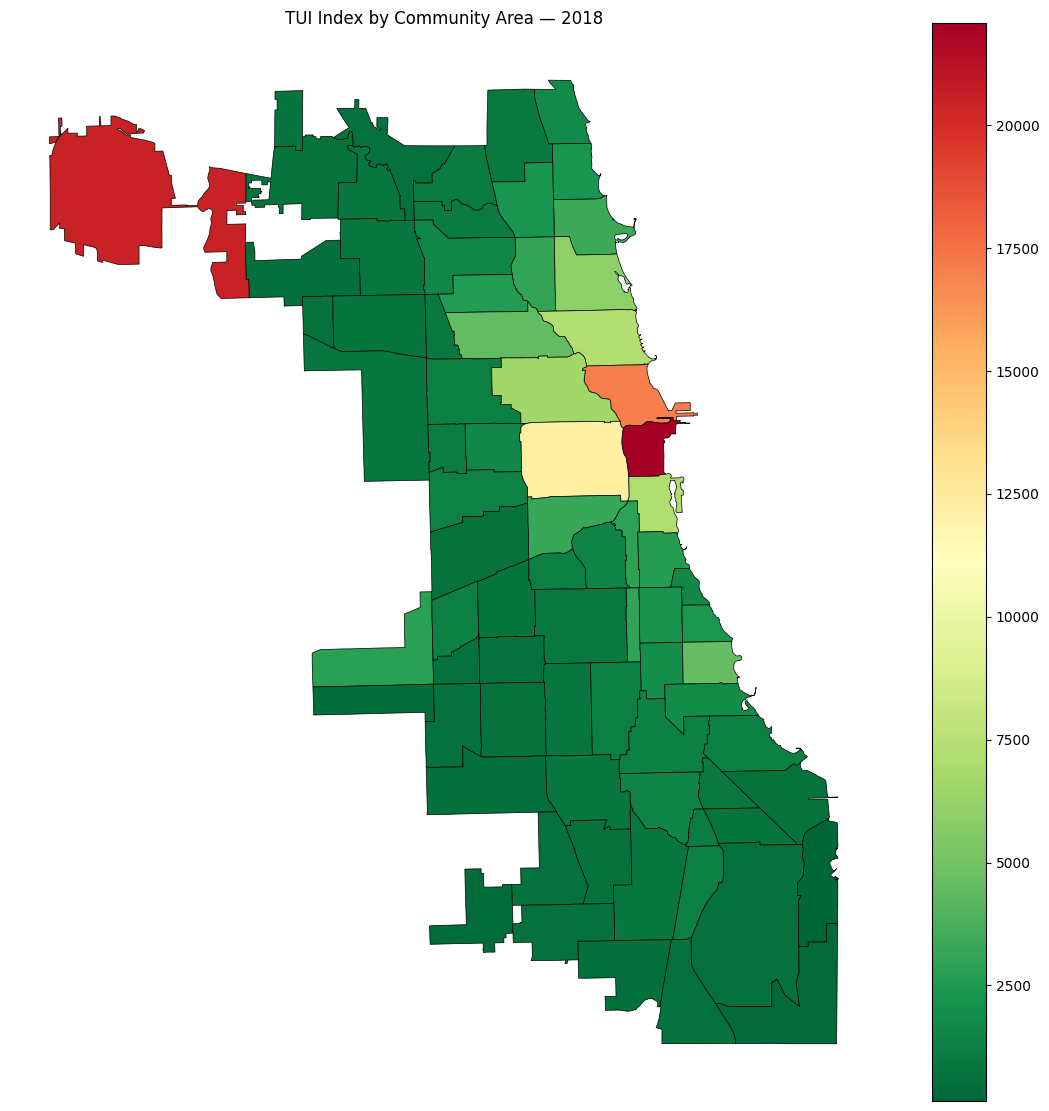

In [130]:
ax = plot_tui_index(tui_map_2018, year=2018, add_labels=False)
save_chart(ax, "tui_2018")
plt.show()

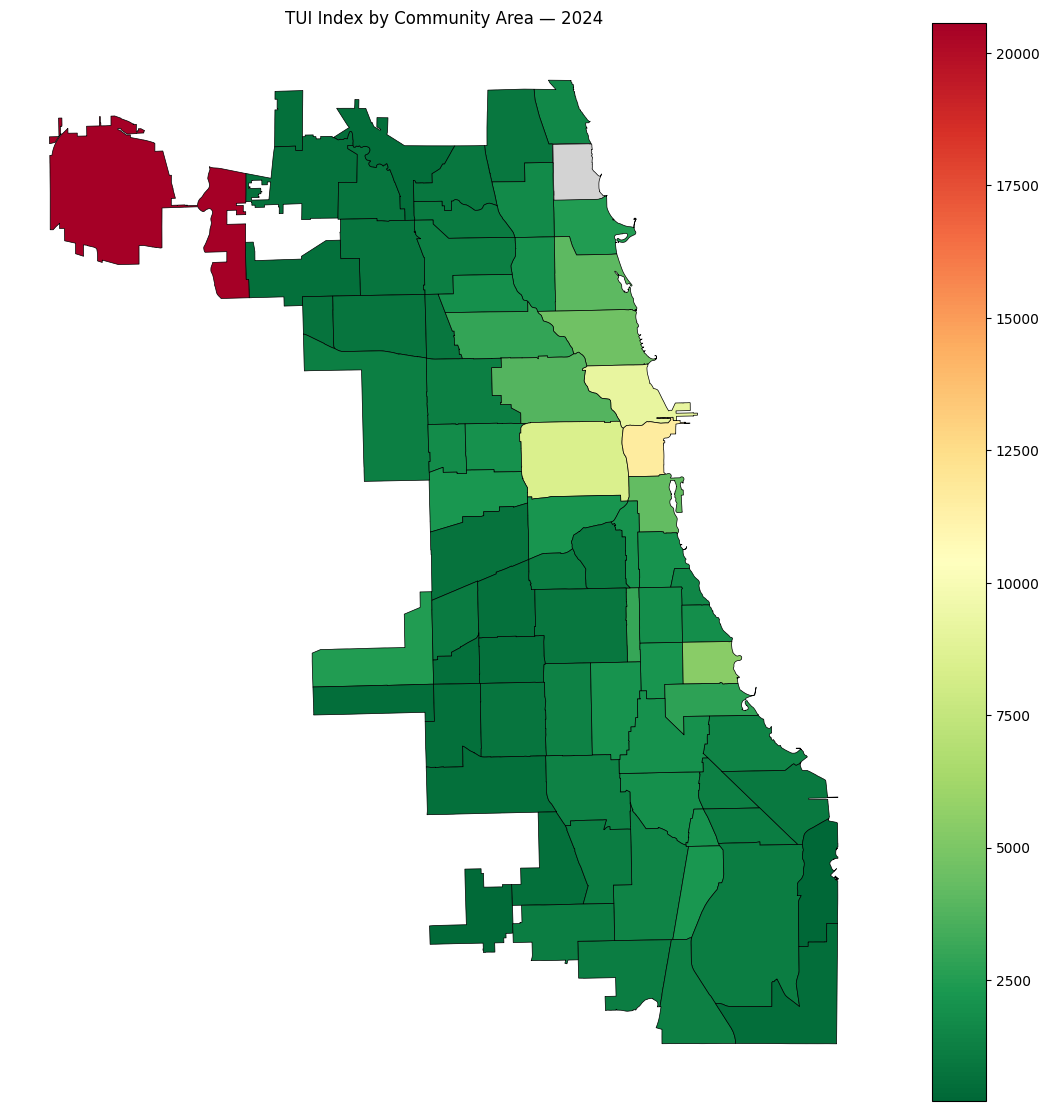

In [131]:
ax = plot_tui_index(tui_map_2024, year=2024, add_labels=False)
save_chart(ax, "tui_2024")
plt.show()

## 3. Socio-Demographic Vulnerability Index (SDVI)

Composite index combining **Hardship Index** and **per capita income** (income enters as disadvantage: lower income implies higher vulnerability). Higher SDVI values indicate greater socio-demographic vulnerability.

**HSVI** (baseline): `mean(z(Hardship), z(CCVI))`. **CCVI** is kept as an auxiliary health indicator.

Community Area 76 (O'Hare) is excluded from socio-demographic modelling.

In [132]:
vulnerability = load_vulnerability_data("data")
analysis_gdf = build_analysis_gdf(tui_map_2024, vulnerability)

print(f"Community Areas in analysis (excl. O'Hare): {len(analysis_gdf)}")
analysis_gdf[[
    "community_area", "community_area_name", "tui_index",
    "hardship_index", "per_capita_income", "hsvi", "sdvi", "ccvi_score",
]].head()

Community Areas in analysis (excl. O'Hare): 75


,community_area,community_area_name,tui_index,hardship_index,per_capita_income,hsvi,sdvi,ccvi_score
0,1,ROGERS PARK,1589.021917,39.0,23939,-0.426475,-0.129999,30.9
1,2,WEST RIDGE,872.629786,46.0,23040,-0.133205,0.021385,36.0
2,3,UPTOWN,2516.201448,20.0,35787,-0.975891,-0.848483,24.4
3,4,LINCOLN SQUARE,1680.655769,17.0,37524,-1.343862,-0.957555,15.0
4,5,NORTH CENTER,1983.218853,6.0,57123,-1.904987,-1.790035,4.0


## 4. TUI vs vulnerability

Pearson and Spearman correlations between mean TUI (2024) and HSVI, SDVI, and CCVI. Side-by-side choropleth maps compare spatial patterns.

=== Pearson ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.472,-0.542,-0.515
hsvi,-0.472,1.000,0.957,0.950
sdvi,-0.542,0.957,1.000,0.857
ccvi_score,-0.515,0.950,0.857,1.000



=== Spearman ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.174,-0.120,-0.255
hsvi,-0.174,1.000,0.960,0.925
sdvi,-0.120,0.960,1.000,0.797
ccvi_score,-0.255,0.925,0.797,1.000


TUI vs HSVI: r=-0.472 (p=0.0000), rho=-0.174 (p=0.1344)
TUI vs SDVI: r=-0.542 (p=0.0000), rho=-0.120 (p=0.3061)
TUI vs CCVI: r=-0.515 (p=0.0000), rho=-0.255 (p=0.0274)


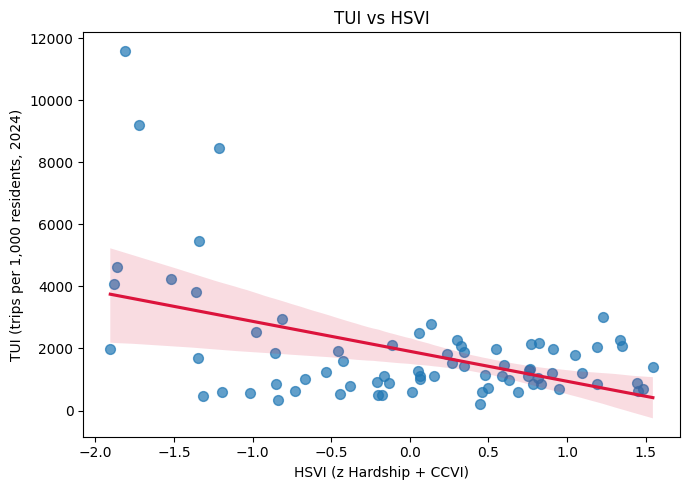

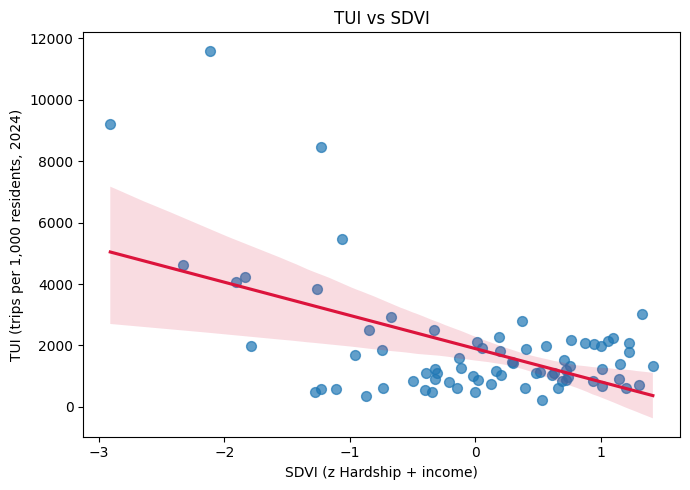

In [133]:
pearson, spearman, tests = compute_tui_correlations(analysis_gdf)

print("=== Pearson ===")
display(pearson.round(3))
print("\n=== Spearman ===")
display(spearman.round(3))

for _, row in tests.iterrows():
    print(
        f"TUI vs {row['indicator']}: "
        f"r={row['pearson_r']:.3f} (p={row['pearson_p']:.4f}), "
        f"rho={row['spearman_rho']:.3f} (p={row['spearman_p']:.4f})"
    )

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="hsvi", year=2024)
save_chart(ax, "tui_vs_hsvi_2024")
plt.tight_layout()
plt.show()

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="sdvi", year=2024)
save_chart(ax, "tui_vs_sdvi_2024")
plt.tight_layout()
plt.show()

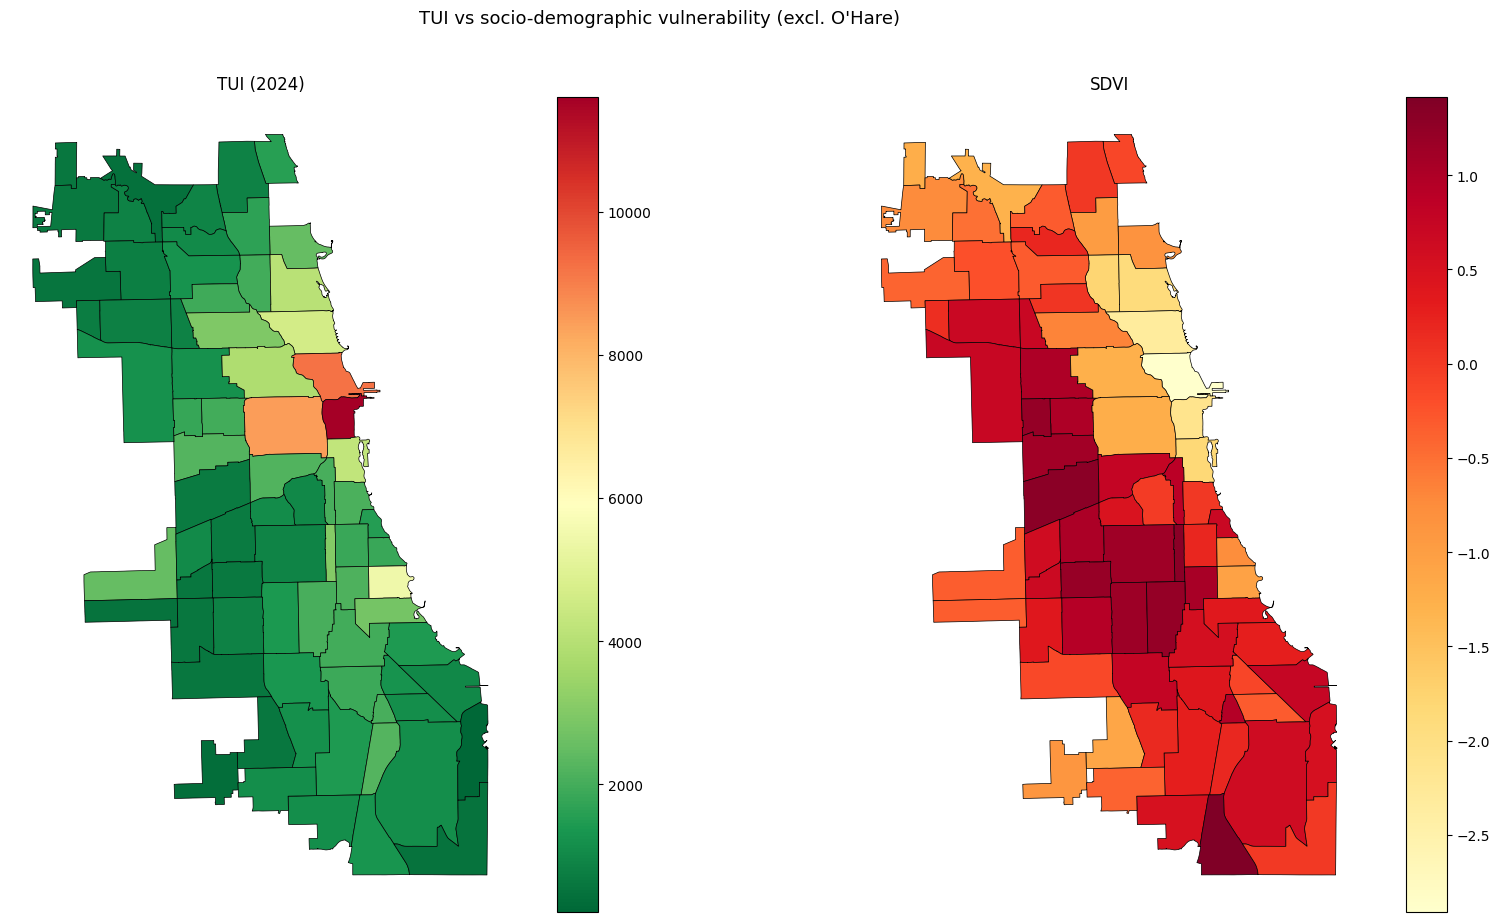

In [134]:
fig = plot_tui_vulnerability_maps(analysis_gdf, year=2024)
save_chart(fig, "tui_sdvi_maps_2024")
plt.show()

## 5. Weighted TUI (Financial Burden Index)

Estimates ridesharing financial burden per Community Area:

$$\text{total\_spend}_i = \text{n\_trips}_i \times \text{avg\_trip\_cost}$$
$$\text{rideshare\_spend\_pc}_i = \frac{\text{total\_spend}_i}{\text{population}_i}$$
$$\text{Weighted\_TUI}_i = \frac{\text{rideshare\_spend\_pc}_i}{\text{per\_capita\_income}_i}$$

Trip counts come from aggregated TNP data; a uniform mean trip cost proxy is applied because fare is not available in the count files. O'Hare (CA 76) excluded.

Avg trip cost proxy: $17.50


,community_area,n_trips,total_spend,rideshare_spend_pc,per_capita_income,Weighted_TUI
36,37,6703,117302.5,52.853019,10432,0.005066
27,28,554909,9710907.5,148.075014,44689,0.003313
28,29,68687,1202022.5,39.528511,12034,0.003285
31,32,483198,8455965.0,202.922056,65526,0.003097
67,68,44502,778785.0,36.429273,11888,0.003064
25,26,29319,513082.5,31.335196,10934,0.002866
46,47,4598,80465.0,35.825913,12515,0.002863
53,54,10298,180215.0,23.054241,8201,0.002811
39,40,26419,462332.5,37.387393,13785,0.002712
26,27,39174,685545.0,34.447766,12961,0.002658


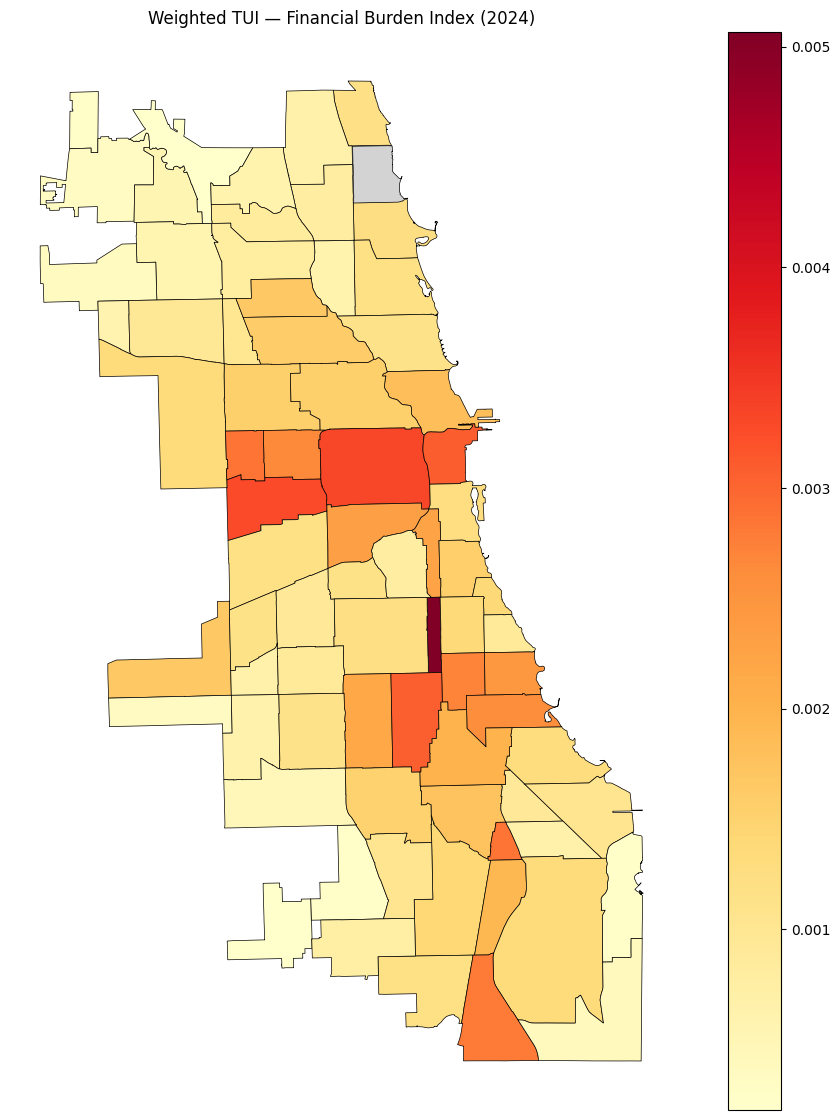

In [135]:
weighted_tui_df = compute_weighted_tui(
    df,
    vulnerability,
    year=2024,
    avg_trip_cost_usd=DEFAULT_AVG_TRIP_COST_USD,
)
weighted_tui_map = build_weighted_tui_map(chicago_community_areas, weighted_tui_df)

print(f"Avg trip cost proxy: ${DEFAULT_AVG_TRIP_COST_USD:.2f}")
display(
    weighted_tui_df[
        ["community_area", "n_trips", "total_spend", "rideshare_spend_pc", "per_capita_income", "Weighted_TUI"]
    ].sort_values("Weighted_TUI", ascending=False).head(10)
)

ax = plot_weighted_tui_map(weighted_tui_map, year=2024)
save_chart(ax, "weighted_tui_2024")
plt.show()

## 6. Ridesharing travel time to the Loop

Mean `trip_seconds` for TNP trips with **dropoff Community Area 32** (Loop), grouped by pickup Community Area. O'Hare (CA 76) excluded from origins. Values are aggregated from the trip-level TNP API (monthly queries, cached locally).

  2024-01: 76 pickup areas
  2024-02: 76 pickup areas
  2024-03: 76 pickup areas
  2024-04: 76 pickup areas
  2024-05: 76 pickup areas
  2024-06: 76 pickup areas
  2024-07: 76 pickup areas
  2024-08: 76 pickup areas
  2024-09: 76 pickup areas
  2024-10: 76 pickup areas
  2024-11: 76 pickup areas
  2024-12: 76 pickup areas
Downloaded loop travel times: data/tnp_loop_travel_times_2024.csv


,community_area,mean_trip_seconds,n_trips,mean_trip_minutes
8,9,2564.749049,1052.0,42.745817
9,10,2444.581327,5441.0,40.743022
16,17,2297.853565,5470.0,38.297559
17,18,2296.387332,1784.0,38.273122
73,74,2296.312925,1029.0,38.271882
69,70,2277.188963,5255.0,37.953149
54,55,2263.016393,1037.0,37.716940
11,12,2192.315251,3226.0,36.538588
12,13,2128.041418,5022.0,35.467357
53,54,2059.400742,1078.0,34.323346


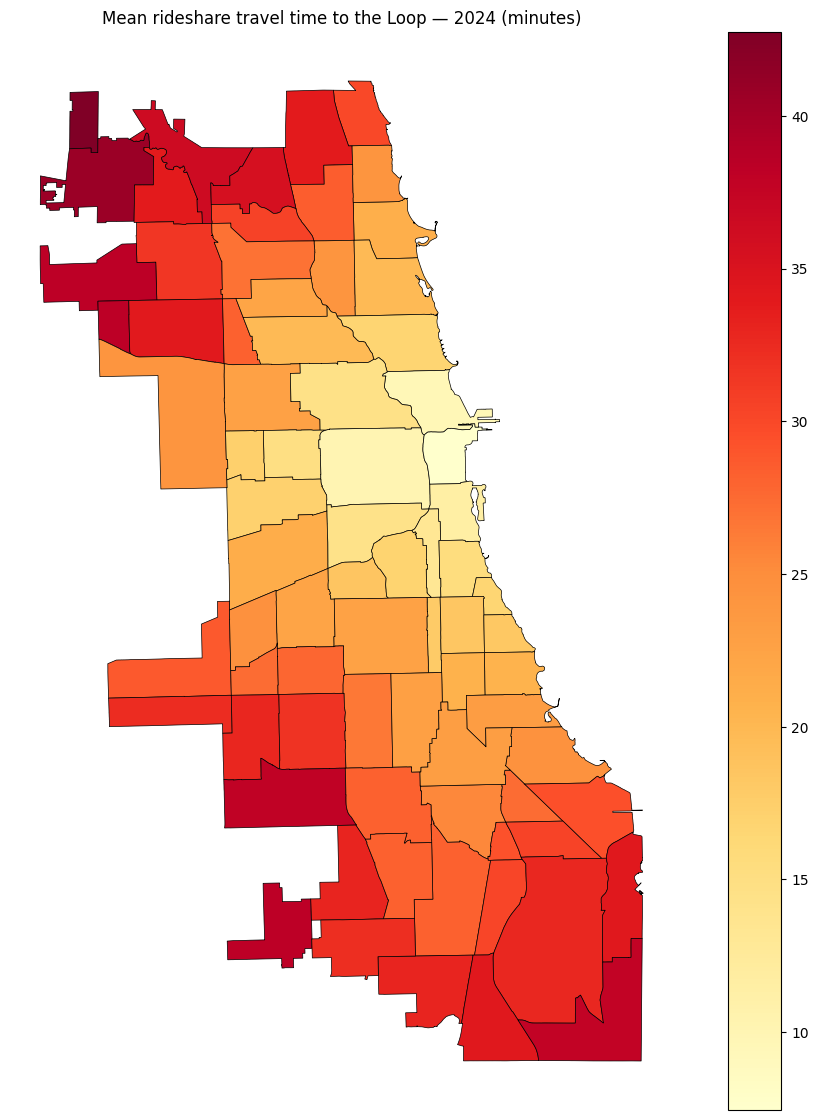

In [136]:
source_loop_travel_times(url_2023_2024, "tnp_loop_travel_times_2024", year=2024)
loop_travel_df = pd.read_csv("data/tnp_loop_travel_times_2024.csv")
loop_travel_df["community_area"] = loop_travel_df["community_area"].astype(int)

loop_travel_map = build_loop_travel_time_map(chicago_community_areas, loop_travel_df)
loop_travel_map["mean_trip_minutes"] = loop_travel_map["mean_trip_seconds"] / 60

display(
    loop_travel_df.assign(mean_trip_minutes=loop_travel_df["mean_trip_seconds"] / 60)
    .sort_values("mean_trip_seconds", ascending=False)
    .head(10)
)

ax = plot_loop_travel_time_map(loop_travel_map, year=2024)
save_chart(ax, "loop_travel_time_2024")
plt.show()